In [1]:
from google.colab import files
uploaded = files.upload()


Saving df_clean.csv to df_clean.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

df = pd.read_csv('df_clean.csv')

X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y = np.log1p(df['SI'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
print('LinearRegression R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


LinearRegression R2: 0.152 RMSE: 1.433


In [4]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print('RandomForest R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


RandomForest R2: 0.336 RMSE: 1.267


In [5]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
pred = gb.predict(X_test)
print('GradientBoosting R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


GradientBoosting R2: 0.287 RMSE: 1.314


In [6]:
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print('XGBoost R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


XGBoost R2: 0.211 RMSE: 1.381


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)
pred = grid_rf.predict(X_test)
print('RF tuned R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
RF tuned R2: 0.346 RMSE: 1.258


In [8]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
grid_gb.fit(X_train, y_train)
print(grid_gb.best_params_)
pred = grid_gb.predict(X_test)
print('GB tuned R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
GB tuned R2: 0.28 RMSE: 1.32


SI предсказывается хуже всего: R2=0.346 у лучшей модели. Тюнинг дал минимальный прирост, что дает нам предположить, что дело не в гиперпараметрах, а в том что признаки почти не связаны с SI ( т.к. макс корреляция 0.16 в EDA). Потолок качества низкий из-за природы данных.

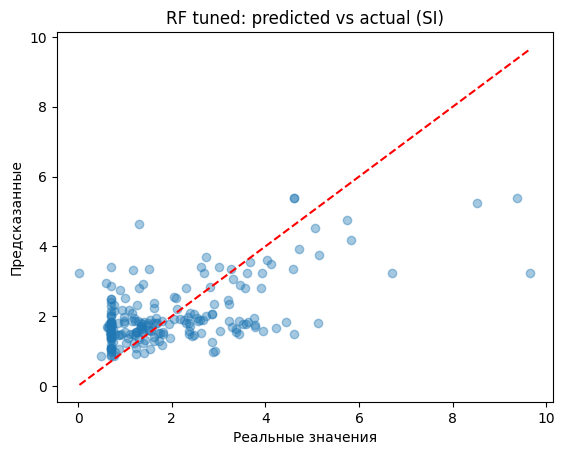

In [9]:
import matplotlib.pyplot as plt

best_pred = grid_rf.predict(X_test)

plt.scatter(y_test, best_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные')
plt.title('RF tuned: predicted vs actual (SI)')
plt.show()

Разброс на графике самый большой из трёх таргетов. Это ожидаемо: SI = CC50/IC50, нелинейная зависимость, признаки почти не коррелируют с ним. Возможно лучше всего предсказывать CC50 и IC50 отдельно, а SI считать из них.

Попробуем другой подход: SI = CC50/IC50. Обучим модели на CC50 и IC50 отдельно, а SI посчитаем из предсказаний.

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# таргеты в исходном масштабе (без log)
y_ic50 = df['IC50, mM'].iloc[y_test.index]
y_cc50 = df['CC50, mM'].iloc[y_test.index]

# обучаем RF на IC50 и CC50
rf_ic50 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_ic50.fit(X_train, np.log1p(df['IC50, mM'].iloc[X_train.index]))
pred_ic50 = np.expm1(rf_ic50.predict(X_test))

rf_cc50 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_cc50.fit(X_train, np.log1p(df['CC50, mM'].iloc[X_train.index]))
pred_cc50 = np.expm1(rf_cc50.predict(X_test))

# считаем SI из предсказаний
pred_si = pred_cc50 / pred_ic50
real_si = df['SI'].iloc[y_test.index]

r2 = r2_score(real_si, pred_si)
print(f'SI через CC50/IC50: R2 = {round(r2, 3)}')

SI через CC50/IC50: R2 = -0.007


Косвенный метод дал R2=-0.007, хуже нуля, то есть хуже чем просто предсказывать среднее. Ошибки предсказания IC50 и CC50 умножаются при делении, результат получается хуже прямого.

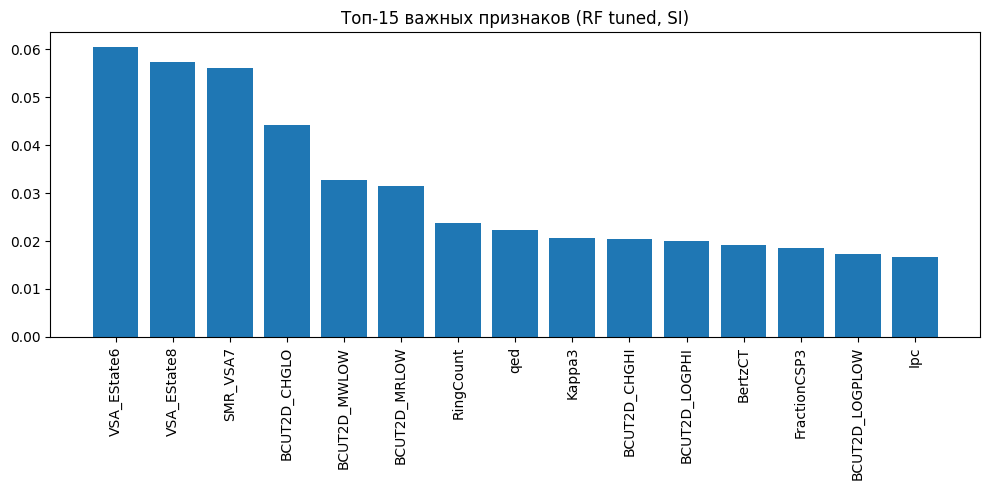

In [11]:
importances = grid_rf.best_estimator_.feature_importances_
feat_names = X.columns
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), importances[top_idx])
plt.xticks(range(15), feat_names[top_idx], rotation=90)
plt.title('Топ-15 важных признаков (RF tuned, SI)')
plt.tight_layout()
plt.show()


Для SI важные признаки распределены равномерно, все в диапазоне 0.02–0.06, нет явного лидера как у IC50 (VSA_EState8 с 0.14). В топе VSA_EState6, VSA_EState8, SMR_VSA7. Равномерное распределение важности говорит о том что SI зависит от многих слабых сигналов одновременно, а не от одного признака, именно поэтому его так сложно предсказывать.